In [5]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [6]:
df_brasil = pd.read_excel(
    'Tabela_13_Meio_de_transporte.xlsx',
    sheet_name='Exemplo gráfico Brasil',
    header=1
)

# Renomeia a primeira coluna para facilitar o uso
df_brasil = df_brasil.rename(columns={df_brasil.columns[0]: 'Meio de Transporte'})

df_brasil

FileNotFoundError: [Errno 2] No such file or directory: 'Tabela_13_Meio_de_transporte.xlsx'

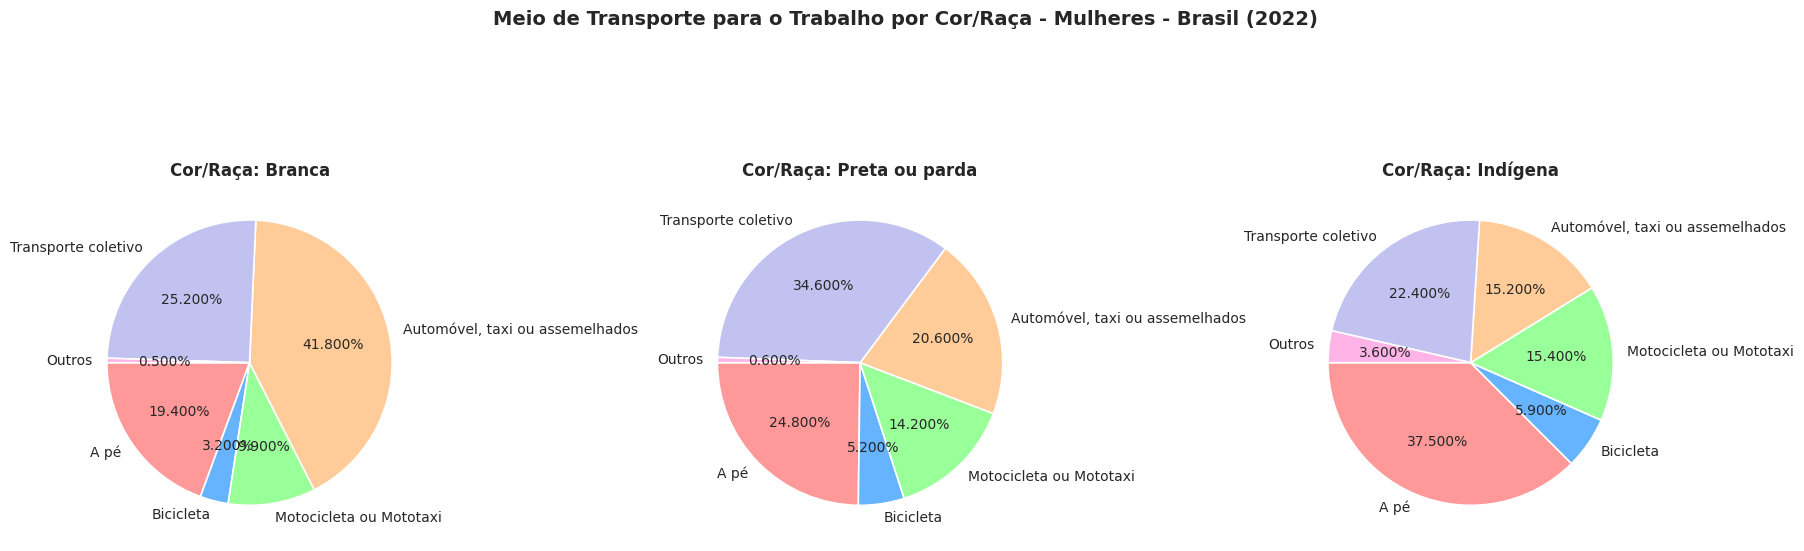

In [3]:
df = df_brasil  # apelido usado no template

TAMANHO = (18, 7)
fig, axes = plt.subplots(1, 3, figsize=TAMANHO)
cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

grupos = ['Branca', 'Preta ou parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=df['Meio de Transporte'],
        autopct='%1.3f%%',  # 3 casas decimais
        startangle=180,     # Ângulo inicial de rotação
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Meio de Transporte para o Trabalho por Cor/Raça - Mulheres - Brasil (2022)',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300)
plt.show()

In [4]:
raw = pd.read_excel('Tabela_13_Meio_de_transporte.xlsx', sheet_name='BR GR UF MU', header=None)

# Linha 1 = grupo de cor/raça (propagado com ffill), linha 2 = meio de transporte
racas = raw.iloc[1].ffill()
modos = raw.iloc[2]

colunas = [('Local', '')] + list(zip(racas[1:], modos[1:]))
mi = pd.MultiIndex.from_tuples(colunas)

df_geo = raw.iloc[3:].copy()
df_geo.columns = mi
df_geo = df_geo.reset_index(drop=True)
df_geo[('Local', '')] = df_geo[('Local', '')].astype(str)

# Converte todas as colunas de percentuais para número
for c in df_geo.columns[1:]:
    df_geo[c] = pd.to_numeric(df_geo[c], errors='coerce')

df_geo.head()

Local Branca                                    \
              A pé Bicicleta Motocicleta ou Mototaxi   
0    Brasil   19.4       3.2                     9.9   
1     Norte   15.2       5.9                    24.5   
2  Nordeste   24.9       2.6                    19.9   
3   Sudeste   18.5       2.7                     7.1   
4       Sul   20.8       3.5                     7.3   

                                                             Preta ou Parda  \
  Automóvel, taxi ou assemelhados Transporte coletivo Outros           A pé   
0                            41.8                25.2    0.5           24.8   
1                            35.1                17.9    1.3           21.3   
2                            31.6                20.5    0.5           31.7   
3                            40.4                30.8    0.5           23.0   
4                            48.0                20.0    0.5           24.0   

                                                                     \
  Bicicleta Motocicleta ou Mototaxi Automóvel, taxi ou assemelhados   
0       5.2                    14.2                            20.6   
1       8.6                    27.7                            19.5   
2       4.1                    20.8                            16.9   
3       4.5                     7.0                            19.5   
4       5.5                     8.6                            29.2   

                             Indígena                                    \
  Transporte coletivo Outros     A pé Bicicleta Motocicleta ou Mototaxi   
0                34.6    0.6     37.5       5.9                    15.4   
1                20.8    2.1     46.8       4.8                    19.2   
2                26.0    0.6     42.0       4.2                    19.4   
3                45.5    0.5     26.2       5.6                     5.9   
4                32.2    0.5     31.1       3.1                     5.7   

                                                              
  Automóvel, taxi ou assemelhados Transporte coletivo Outros  
0                            15.2                22.4    3.6  
1                             9.5                 9.1   10.6  
2                            13.1                20.6    0.7  
3                            22.3                39.4    0.6  
4                            22.8                36.4    1.0

In [5]:
estados = df_geo.iloc[6:33].copy().reset_index(drop=True)
municipios = df_geo.iloc[33:].copy().reset_index(drop=True)

print(f"Total de estados: {len(estados)}")
estados[('Local', '')].tolist()

Total de estados: 27


['Rondônia',
 'Acre',
 'Amazonas',
 'Roraima',
 'Pará',
 'Amapá',
 'Tocantins',
 'Maranhão',
 'Piauí',
 'Ceará',
 'Rio Grande do Norte',
 'Paraíba',
 'Pernambuco',
 'Alagoas',
 'Sergipe',
 'Bahia',
 'Minas Gerais',
 'Espírito Santo',
 'Rio de Janeiro',
 'São Paulo',
 'Paraná',
 'Santa Catarina',
 'Rio Grande do Sul',
 'Mato Grosso do Sul',
 'Mato Grosso',
 'Goiás',
 'Distrito Federal']

In [6]:
racas_lista = ['Branca', 'Preta ou Parda', 'Indígena']

# Coluna "geral" = média simples entre as 3 raças, para Transporte coletivo
# (usamos uma tupla ('Transporte coletivo (geral)', '') para manter o MultiIndex consistente)
estados = estados.copy()
estados[('Transporte coletivo (geral)', '')] = estados[
    [(r, 'Transporte coletivo') for r in racas_lista]
].mean(axis=1)

estados_ordenado = estados[[('Local',''), ('Transporte coletivo (geral)', '')]].sort_values(
    ('Transporte coletivo (geral)', ''), ascending=False
)
estados_ordenado.columns = ['Estado', 'Transporte coletivo (geral) %']
estados_ordenado

,Estado,Transporte coletivo (geral) %
18,Rio de Janeiro,52.233333
26,Distrito Federal,46.000000
19,São Paulo,40.733333
22,Rio Grande do Sul,36.100000
14,Sergipe,33.400000
17,Espírito Santo,32.633333
20,Paraná,27.566667
16,Minas Gerais,27.100000
25,Goiás,25.100000
12,Pernambuco,25.033333


In [7]:
mais_coletivo = estados.loc[estados[('Transporte coletivo (geral)', '')].idxmax()]
print(f"Estado: {mais_coletivo[('Local','')]}")
print(f"Uso de transporte coletivo (média entre raças): {mais_coletivo[('Transporte coletivo (geral)', '')]:.2f}%")

Estado: Rio de Janeiro
Uso de transporte coletivo (média entre raças): 52.23%


In [8]:
menos_coletivo = estados.loc[estados[('Transporte coletivo (geral)', '')].idxmin()]
print(f"Estado: {menos_coletivo[('Local','')]}")
print(f"Uso de transporte coletivo (média entre raças): {menos_coletivo[('Transporte coletivo (geral)', '')]:.2f}%")

Estado: Rondônia
Uso de transporte coletivo (média entre raças): 4.33%


**Pergunta 3: Qual cidade do Brasil tem mais mulheres andando de bicicleta?**

In [9]:
municipios[('Bicicleta (geral)', '')] = municipios[
    [(r, 'Bicicleta') for r in racas_lista]
].mean(axis=1)

top_bike = municipios.loc[municipios[('Bicicleta (geral)', '')].idxmax()]
print(f"Cidade: {top_bike[('Local','')]}")
print(f"Uso de bicicleta (média entre raças): {top_bike[('Bicicleta (geral)', '')]:.2f}%")

# Top 10 para dar contexto
municipios[[('Local',''), ('Bicicleta (geral)', '')]].sort_values(
    ('Bicicleta (geral)', ''), ascending=False
).head(10)

Cidade: Tuiuti (SP)
Uso de bicicleta (média entre raças): 100.00%


,Local,Bicicleta (geral)
,,
3882,Tuiuti (SP),100.000000
154,Afuá (PA),72.050000
5268,Novo Santo Antônio (MT),68.900000
2673,Lagoa Grande (MG),67.866667
5360,Britânia (GO),64.466667
335,Bom Jesus do Tocantins (TO),64.366667
3059,Tumiritinga (MG),63.866667
5212,Cocalinho (MT),59.266667
2878,Riachinho (MG),59.050000


**Pergunta 4: Qual cidade do Brasil tem mais mulheres utilizando carro?**

In [10]:
municipios[('Automóvel (geral)', '')] = municipios[
    [(r, 'Automóvel, taxi ou assemelhados') for r in racas_lista]
].mean(axis=1)

top_car = municipios.loc[municipios[('Automóvel (geral)', '')].idxmax()]
print(f"Cidade: {top_car[('Local','')]}")
print(f"Uso de automóvel/táxi (média entre raças): {top_car[('Automóvel (geral)', '')]:.2f}%")

# Top 10 para dar contexto
municipios[[('Local',''), ('Automóvel (geral)', '')]].sort_values(
    ('Automóvel (geral)', ''), ascending=False
).head(10)

Cidade: Bom Jesus do Oeste (SC)
Uso de automóvel/táxi (média entre raças): 86.05%


,Local,Automóvel (geral)
,,
4352,Bom Jesus do Oeste (SC),86.050000
4351,Bom Jesus (SC),74.566667
5071,Tupanci do Sul (RS),74.550000
3896,Valinhos (SP),71.433333
3707,Piratininga (SP),71.400000
4416,Ibiam (SC),70.350000
4660,Bozano (RS),69.400000
4724,Coronel Pilar (RS),68.800000
3644,Nova Odessa (SP),68.566667
